"KNN
predictive maintenance: notebook approach ZOHAIB HASSAN"

In [2]:
%pip install mlflow azureml-mlflow seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install "numpy<2" "pandas<2.2" --force-reinstall --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,roc_auc_score, classification_report,ConfusionMatrixDisplay)
df = pd.read_csv("../data/ai4i_clean.csv")
TARGET = "machine_failure"
NUM_COLS = ["air_temp_k", "process_temp_k", "rpm", "torque_nm","tool_wear_min"]
CAT_COLS = ["type"]
# Use float for all sensor columns so the deployed model accepts decimal inputs
df[NUM_COLS] = df[NUM_COLS].astype(float)
print(df.shape)
df.head()

(10000, 7)


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551.0,42.8,0.0,0
1,L,298.2,308.7,1408.0,46.3,3.0,0
2,L,298.1,308.5,1498.0,49.4,5.0,0
3,L,298.2,308.6,1433.0,39.5,7.0,0
4,L,298.2,308.7,1408.0,40.0,9.0,0


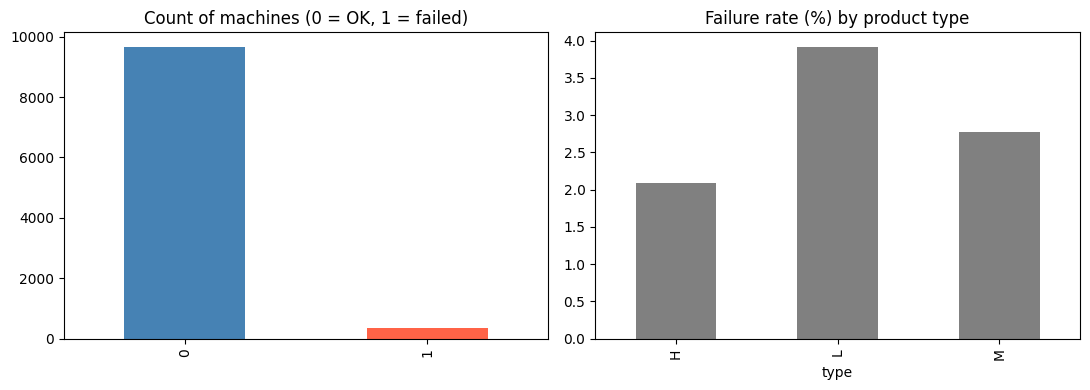

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue","tomato"])
axes[0].set_title("Count of machines (0 = OK, 1 = failed)")
df.groupby("type")[TARGET].mean().mul(100).plot(kind="bar", ax=axes[1],color="gray")
axes[1].set_title("Failure rate (%) by product type")
plt.tight_layout()
plt.show()

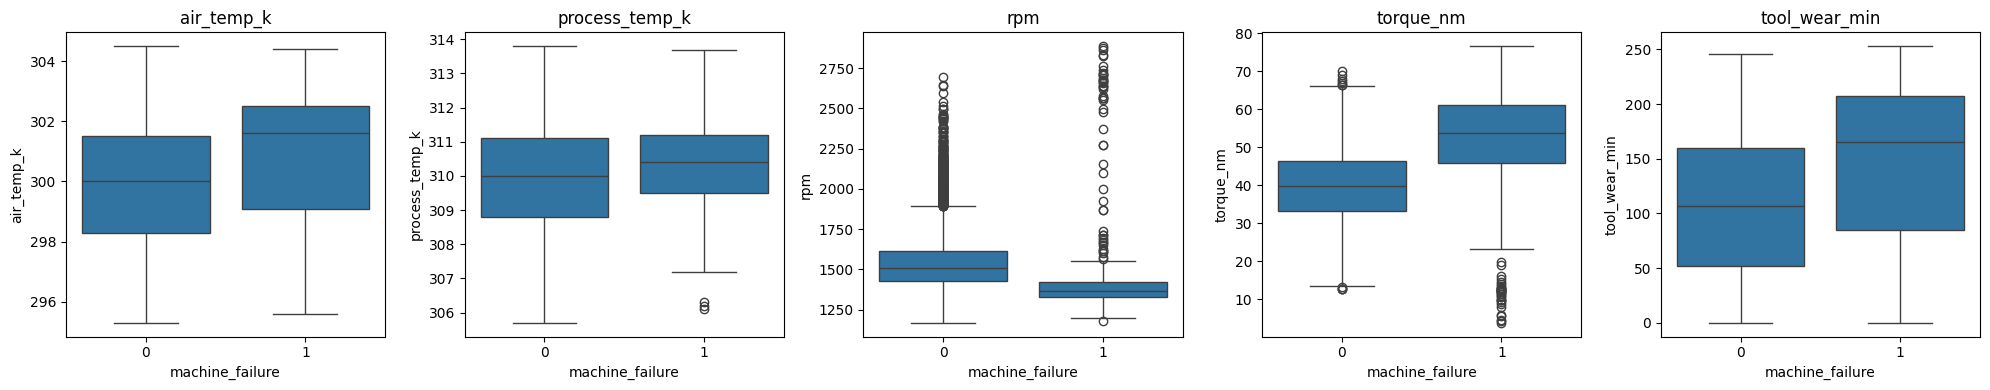

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, NUM_COLS):
 sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
 ax.set_title(col)
plt.tight_layout()
plt.show()

In [4]:
df[NUM_COLS].describe().T[["min", "max", "mean", "std"]].round(1)

,min,max,mean,std
air_temp_k,295.3,304.5,300.0,2.0
process_temp_k,305.7,313.8,310.0,1.5
rpm,1168.0,2886.0,1538.8,179.3
torque_nm,3.8,76.6,40.0,10.0
tool_wear_min,0.0,253.0,108.0,63.7


In [5]:
X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]
# stratify=y keeps the same 3.4% failure rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "failure rate", round(y_train.mean(), 4))
print("Test: ", X_test.shape, "failure rate", round(y_test.mean(), 4))

Train: (8000, 6) failure rate 0.0339
Test:  (2000, 6) failure rate 0.034


In [16]:
def make_pipeline(scale=True, k=5):
    num_step = StandardScaler() if scale else "passthrough"
    prep = ColumnTransformer([
        ("num", num_step, NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])
    return Pipeline([
        ("prep", prep),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])


for scale in [False, True]:
    model = make_pipeline(scale=scale).fit(X_train, y_train)
    pred = model.predict(X_test)
    print(
        f"Scaling={str(scale):5} "
        f"accuracy={accuracy_score(y_test, pred):.3f} "
        f"recall={recall_score(y_test, pred):.3f} "
        f"F1={f1_score(y_test, pred):.3f}"
    )

Scaling=False accuracy=0.970 recall=0.206 F1=0.318
Scaling=True  accuracy=0.974 recall=0.294 F1=0.435


In [18]:
param_grid = {
"knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
"knn__weights": ["uniform", "distance"],
"knn__p": [1, 2], # 1 = Manhattan distance, 2 = Euclideandistance
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(make_pipeline(scale=True), param_grid,
scoring="f1", cv=cv, n_jobs=-1)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

Best parameters: {'knn__n_neighbors': 1, 'knn__p': 1, 'knn__weights': 'uniform'}
Best cross-validated F1: 0.509


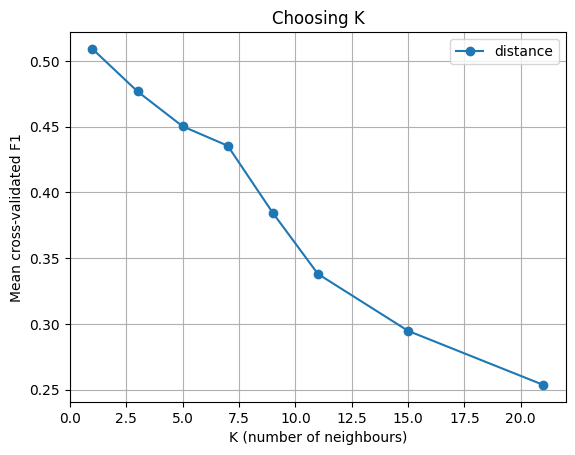

In [20]:
res = pd.DataFrame(grid.cv_results_)
res = res[res["param_knn__p"] == grid.best_params_["knn__p"]]
for w in ["uniform", "distance"]:
 sub = res[res["param_knn__weights"] == w]
plt.plot(sub["param_knn__n_neighbors"].astype(int),
sub["mean_test_score"], marker="o", label=w)
plt.xlabel("K (number of neighbours)")
plt.ylabel("Mean cross-validated F1")
plt.title("Choosing K")
plt.legend()
plt.grid(True)
plt.show()

{'accuracy': 0.964, 'precision': 0.453, 'recall': 0.353, 'f1': 0.397, 'auc': 0.669}
              precision    recall  f1-score   support

          OK       0.98      0.98      0.98      1932
     Failure       0.45      0.35      0.40        68

    accuracy                           0.96      2000
   macro avg       0.72      0.67      0.69      2000
weighted avg       0.96      0.96      0.96      2000



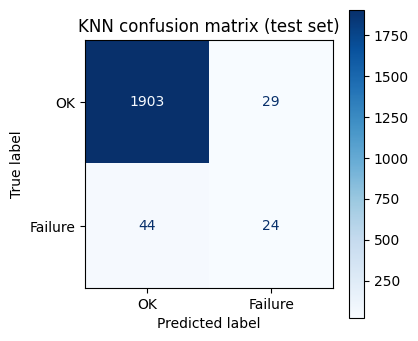

In [21]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
metrics = {
"accuracy": accuracy_score(y_test, y_pred),
"precision": precision_score(y_test, y_pred),
"recall": recall_score(y_test, y_pred),
"f1": f1_score(y_test, y_pred),
"auc": roc_auc_score(y_test, y_prob),
}
print({k: round(v, 3) for k, v in metrics.items()})
print(classification_report(y_test, y_pred, target_names=["OK", "Failure"]))
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["OK",
"Failure"],

cmap="Blues", ax=ax)

ax.set_title("KNN confusion matrix (test set)")
fig.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

In [23]:
for t in [0.5, 0.4, 0.3, 0.2]:
 p = (y_prob >= t).astype(int)
print(f"threshold={t}: recall={recall_score(y_test, p):.3f} "f"precision={precision_score(y_test, p, zero_division=0):.3f}")

threshold=0.2: recall=0.353 precision=0.453


In [27]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
SUBSCRIPTION_ID = "48b470e1-2c96-449b-8d68-d475b32d0a68"
RESOURCE_GROUP = "rg-mlab1-Zohaib-hassan"
WORKSPACE = "mlw-lab1-Zohaib-hassan"
ml_client = MLClient(DefaultAzureCredential(), SUBSCRIPTION_ID,RESOURCE_GROUP, WORKSPACE)
mlflow.set_tracking_uri(ml_client.workspaces.get(WORKSPACE).mlflow_tracking_uri)
mlflow.set_experiment("knn-predictive-maintenance")

Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


<Experiment: artifact_location='', creation_time=1791058864822, experiment_id='233ffa89-2d69-4840-af66-cc28793a446a', last_update_time=None, lifecycle_stage='active', name='knn-predictive-maintenance', tags={}>

In [30]:
signature = infer_signature(X_test, best_model.predict(X_test))
with mlflow.start_run(run_name="knn-notebook-gridsearch") as run:
 mlflow.log_params(grid.best_params_)
mlflow.log_param("scaler", "StandardScaler")
mlflow.log_metric("cv_best_f1", grid.best_score_)
mlflow.log_metrics({f"test_{k}": v for k, v in metrics.items()})
mlflow.log_artifact("confusion_matrix.png")
mlflow.sklearn.log_model(
best_model,
artifact_path="model",
signature=signature,
input_example=X_test.head(3),
registered_model_name="knn-maintenance-notebook",
)
print("Run ID:", run.info.run_id)

🏃 View run knn-notebook-gridsearch at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/48b470e1-2c96-449b-8d68-d475b32d0a68/resourceGroups/rg-mlab1-Zohaib-hassan/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-Zohaib-hassan/#/experiments/233ffa89-2d69-4840-af66-cc28793a446a/runs/26629554-7cea-407f-9248-a731ac62de24
🧪 View experiment at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/48b470e1-2c96-449b-8d68-d475b32d0a68/resourceGroups/rg-mlab1-Zohaib-hassan/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-Zohaib-hassan/#/experiments/233ffa89-2d69-4840-af66-cc28793a446a


Registered model 'knn-maintenance-notebook' already exists. Creating a new version of this model...
Created version '3' of model 'knn-maintenance-notebook'.
